# comparing automatic and manual transcriptions of participant audio

In [74]:
import numpy as np
import pandas as pd
import hypertools as hyp
import quail
import pickle
import random
import re
import os
from num2words import num2words
from nltk.corpus import stopwords
from scipy.signal import resample
%matplotlib inline

## choose 5 participants at random to compare

In [2]:
# load in participants dict
with open('../../data/pickles/id_maps.p', 'rb') as file:
    id_maps = pickle.load(file)

# random5 = random.sample(id_maps.keys(), 5)
# print(random5)


# Random 5 chosen:
# ['MD-013119-A-01', 'MD-102218-A-07', 'MD-020119-A-04', 'MD-102218-B-01', 'MD-020119-B-03']

# MD-013119-A-01 did not complete experiment. Replacing with MD-013119-A-02
# MD-020119-B-03 did not complete experiment. Replacing with MD-020119-B-02

In [3]:
random5 = ['MD-013119-A-02', 'MD-102218-A-07', 'MD-020119-A-04', 'MD-102218-B-01', 'MD-020119-B-02']

# get ses1 & ses1 psiturk ids
rand5_turkids = {k: id_maps[k] for k in random5}

### create manual transcription directory structure

In [ ]:
# man_dir = os.path.abspath('../../data/transcriptions/manual')
# for subid, runs in id_maps.items():
#     for ses, turkid in runs.items():
#         folder = os.path.join(man_dir, subid, turkid)
#         if not os.path.isdir(folder) and not os.path.isdir(os.path.join(man_dir,'drops',subid)):
#             os.makedirs(folder, exist_ok=True)

## automatic transcription

### create speech context from union of words in annotations

In [4]:
atlep1_df = pd.read_pickle('../../data/annotations_dfs/atlep1.p')
atlep2_df = pd.read_pickle('../../data/annotations_dfs/atlep2.p')
arrdev_df = pd.read_pickle('../../data/annotations_dfs/arrdev.p')

In [5]:
def meets_word_criteria(string):
    """
    Removes words with characters not wanted in auto transcriber speech context
    """
    
    good_word = True
    
    # remove words containing digits
    if any(char.isdigit() for char in string):
        good_word = False
    
    # remove words surrounded by single quotes and possessives (avoid duplicates in nested quotations & possessives)
    if string.startswith("'") or string.endswith("'") or string.endswith("'s"):
        good_word = False
        
    # remove unhelpful simple words
    if len(string) <= 2:
        good_word = False
    
    return good_word

In [6]:
def create_speech_context(df):
    """
    Creates episode-specific speech context from video annotations
    """
    
    # use Narrative details (internal and external), Characters on screen, Speech, Character speaking, and Setting
    word_cols = [df.columns[i] for i in [2,3,4,6,7,9]]
    
    # create single string of all text
    allwords = ' '.join(df.loc[:,word_cols].apply(lambda x: ' '.join(x.dropna()), axis=1).values.tolist())
    
    # remove all characters except spaces (catches \n and \t), letters, apostrophes, dashes
    no_punctuation = re.sub("[^\w\s'-]+", '', allwords)
    
    speech_context = []
    
    # split words into list
    for word in no_punctuation.split():
        # identify unique words that meet criteria
        if word.lower() not in speech_context and meets_word_criteria(word):
            speech_context.append(word.lower())

    # remove English stopwords
    speech_context_nostop = [word for word in speech_context if word not in stopwords.words('english')]
    
    return speech_context_nostop

In [8]:
atlep1_speech_context = create_speech_context(atlep1_df)
atlep2_speech_context = create_speech_context(atlep2_df)
arrdev_speech_context = create_speech_context(arrdev_df)

In [9]:
audiodir = os.path.abspath('../../data/audio/')
keypath = os.path.abspath('../../../google-credentials/cloud-speech-credentials.json')

# for sid, data in rand5_turkids.items():
#     print(sid + ':')
#     for ses, turkid in data.items():
        
#         # get corrrect audio file names and speech context by session and condition
#         if ses == 'session 1':
#             audiofiles = [turkid+'-recall.wav', turkid+'-prediction.wav']
#         elif ses == 'session 2':
#             audiofiles = [turkid+'-delayed.wav', turkid+'-recall.wav']

#         for audiofile in audiofiles:
            
#             # SKIP ALREADY FINISHED ONE
#             if audiofile != 'debughKp9W:debug1QFCO-recall.wav':
                
#                 # set correct episode speech context
#                 if session == 'session 2' and audiofile.endswith('-recall.txt'):
#                     if 'A' in sid:
#                         episode_context = atlep2_speech_context
#                     elif 'B' in sid:
#                         episode_context = arrdev_speech_context
#                     else:
#                         episode_context = atlep1_speech_context
            
#                 # find file in correct testroom dir
#                 path = os.path.join(audiodir,'room1',turkid, audiofile)
#                 if not os.path.isfile(path):
#                     path = os.path.join(audiodir,'room2',turkid, audiofile)
#                     if not os.path.isfile(path):
#                         print('AUDIO FILE NOT FOUND: ' + path)
#                         break

#                 # and decode the audio
#                 print('\tdecoding ' + ses + ': ' + audiofile + ' ...')
#                 quail.decode_speech(path=path, keypath=keypath, save=True, speech_context=episode_context,
#                                     enable_word_time_offsets=False)


### parse google cloud objects into text files

In [32]:
def parse_response_object(filepath):
    """
    parses Google Cloud RecognizeResponse objects and returns string of full transcript
    """
    
    # load pickled response object
    with open(filepath, 'rb') as f:
        resp_obj = pickle.load(f)
    
    # list for full participant transcript
    full_transcript = []
    # loop over decoded chunks
    for chunk in resp_obj:
        # access transcript
        for result in chunk.results:
            single_transcript = result.alternatives[0].transcript
            # split to list
            transcript_aslist = [word.lower() for word in single_transcript.split(' ')]

            for i, word in enumerate(transcript_aslist):
                # strip punctuation
                if word.endswith('.') or word.endswith(',') or word.endswith(':'):
                    transcript_aslist[i] = word[:-1]
                        
                # convert digits to words
                if word.isdigit():
                    transcript_aslist[i] = num2words(int(word))
                # convert times to words
                if ':' in word:
                    transcript_aslist[i] = ' '.join([num2words(int(i)) for i in transcript_aslist[i].split(':')])
                # convert currency to words
                if '$' in word:
                    transcript_aslist[i] = num2words(word.strip('$').replace(',',''), to='currency', 
                                                     currency='USD').split(',')[0]

            full_transcript.append(' '.join(transcript_aslist))
            
    
    return ' '.join(full_transcript)

In [33]:
# for sid, data in rand5_turkids.items():
#     for ses, tid in data.items():
        
#         # find file in correct test room
#         path = os.path.join(audiodir,'room1',tid)
#         if not os.path.isdir(path):
#             path = os.path.join(audiodir,'room2',tid)
#             if not os.path.isdir(path):
#                 print('ID not found: ' + tid)
#                 break
        
#         # assign correct audio file types
#         if os.path.isfile(os.path.join(path,tid+'-prediction.wav.p')):
#             files = ['-prediction.wav.p', '-recall.wav.p']
#         else:
#             files = ['-delayed.wav.p', '-recall.wav.p']
        
#         # parse each response object and save out text file
#         for file in files:
#             filepath = os.path.join(path,tid+file)
#             transcript = parse_response_object(filepath)
            
#             with open(filepath.rstrip('.p')+'.txt', 'w') as f:
#                 f.write(transcript)
            

## model transcriptions

In [34]:
# folder of manual transcriptions
mandir = '../../data/transcriptions/manual/'

In [101]:
# model parameters
n_topics = 100
episode_wsize = 50
recall_wsize = 200

# vectorizer parameters
vectorizer_params = {
    'model' : 'CountVectorizer', 
    'params' : {
        'stop_words' : 'english'
    }
}

# topic model parameters
semantic_params = {
    'model' : 'LatentDirichletAllocation', 
    'params' : {
        'n_components' : n_topics,
        'learning_method' : 'batch',
        'random_state' : 0,
    }
}

In [36]:
def get_episode_windows(episode_df, episode_wsize):
    # throw all annotations into bag of words to train model
    episode_bag = episode_df.loc[:,'Narrative details (external events)':'Setting'].apply(lambda x: ', '.join(x.fillna('')), axis=1).values.tolist()

    # create list for annotation sliding windows (of size w_size)
    episode_w = []
    for idx, sentence in enumerate(episode_bag):
        episode_w.append(','.join(episode_bag[idx:idx+episode_wsize]))

    return episode_w

In [69]:
# sliding annotation windows for the three episodes
atlep1_windows = get_episode_windows(atlep1_df, episode_wsize)
atlep2_windows = get_episode_windows(atlep2_df, episode_wsize)
arrdev_windows = get_episode_windows(arrdev_df, episode_wsize)

In [96]:
def transform_recall(transcript, n_topics, recall_wsize, vec_params, sem_params, episode_windows, resample_shape):
    """
    transform recalls based on sliding windows of episode annotations
    """
    # sliding windows of episode annotations and recall words
    recall_w = []

    # split recall transcript into list
    rec_list = transcript.split()
    
    # create overlapping windows of recall_wsize words
    for ix, word in enumerate(rec_list):
        recall_w.append(','.join(rec_list[ix:ix+recall_wsize]))
        
    # create recall model
    recall_model = hyp.tools.format_data(recall_w, vectorizer=vec_params, semantic=sem_params,
                                         corpus=episode_windows)[0]
    
    # return recalled model to corresponding episode model length
    return resample(recall_model, resample_shape)

In [97]:
# empty dict of automatic and manual transcription models for each audio file
rec_models_dict = {}

for sid, data in rand5_turkids.items():
    for ses, tid in data.items():
        if ses == 'session 1':  
            rec_models_dict[tid] = {'recall' : {'automatic' : None, 'manual' : None}, 
                                    'prediction' : {'automatic' : None, 'manual' : None} }
        else:
            rec_models_dict[tid] = {'delayed' : {'automatic' : None, 'manual' : None}, 
                                    'recall' : {'automatic' : None, 'manual' : None} }

In [71]:
# load in episode models
models_dir = '../../data/models/video/'
atlep1_model = np.load(models_dir+'atlep1_model.npy')
atlep2_model = np.load(models_dir+'atlep2_model.npy')
arrdev_model = np.load(models_dir+'arrdev_model.npy')

In [102]:
for method in ['automatic', 'manual']:
    for sid, data in rand5_turkids.items():
        for ses, tid in data.items():

            # search in appropriate location for auto/man transcriptions
            if method == 'automatic':
                # find file in correct test room
                path = os.path.join(audiodir,'room1',tid)
                if not os.path.isdir(path):
                    path = os.path.join(audiodir,'room2',tid)
                    if not os.path.isdir(path):
                        print('ID not found: ' + tid)
                        break
            else:
                path = os.path.join(mandir,sid,tid)

            # assign correct transcript file types
            if os.path.isfile(os.path.join(path,tid+'-prediction.wav.txt')) or os.path.isfile(os.path.join(path,tid+'-prediction.txt')):
                files = ['prediction', 'recall']
            elif os.path.isfile(os.path.join(path,tid+'-delayed.wav.txt')) or os.path.isfile(os.path.join(path,tid+'-delayed.txt')):
                files = ['delayed', 'recall']
            else:
                print('No ' + method + ' transcripts found for subject in ' + path)
                break

            for file in files:
                print('modeling ' + tid + ' ' + file + ', '+ method)
                # assign correct annotations dataframe and sliding windows
                if ses == 'session 1' or file == 'delayed':
                    episode_ws = atlep1_windows
                    resample_shape = np.shape(atlep1_model)[0]
                else:
                    if 'A' in sid:
                        episode_ws = atlep2_windows
                        resample_shape = np.shape(atlep2_model)[0]
                    else:
                        episode_ws = arrdev_windows
                        resample_shape = np.shape(arrdev_model)[0]

                if method == 'automatic':
                    filepath = os.path.join(path,tid+'-'+file+'.wav.txt')
                else:
                    filepath = os.path.join(path,tid+'-'+file+'.txt')

                # read in transcript
                with open(filepath, 'r') as f:
                    transcript = f.read()

                # transform transcript
                modeled_transcript = transform_recall(transcript, n_topics, recall_wsize, vectorizer_params, 
                                              semantic_params, episode_ws, resample_shape)
                # add to dictionary
                rec_models_dict[tid][file][method] = modeled_transcript


modeling debug5ytRS:debug22nvn prediction, automatic
modeling debug5ytRS:debug22nvn recall, automatic
modeling debug3Z74G:debug6CQ6D delayed, automatic
modeling debug3Z74G:debug6CQ6D recall, automatic
modeling debugWvhTI:debug65Thd prediction, automatic
modeling debugWvhTI:debug65Thd recall, automatic
modeling debugTkyN6:debugdsr6W delayed, automatic
modeling debugTkyN6:debugdsr6W recall, automatic
modeling debugo1MpX:debugfpXYH prediction, automatic
modeling debugo1MpX:debugfpXYH recall, automatic
modeling debugeyj0U:debugsaXvf delayed, automatic
modeling debugeyj0U:debugsaXvf recall, automatic
modeling debugqWZVC:debugZSccI prediction, automatic
modeling debugqWZVC:debugZSccI recall, automatic
modeling debugRvgf2:debugpnybj delayed, automatic
modeling debugRvgf2:debugpnybj recall, automatic
modeling debugAU1cu:debugzdGmZ prediction, automatic
modeling debugAU1cu:debugzdGmZ recall, automatic
modeling debug27k0b:debugOGsyi delayed, automatic
modeling debug27k0b:debugOGsyi recall, autom

In [103]:
with open('../../data/pickles/transcription_comparison_models_w%s_resampled.p' % str(recall_wsize), 'wb') as file:
    pickle.dump(rec_models_dict, file)

recall


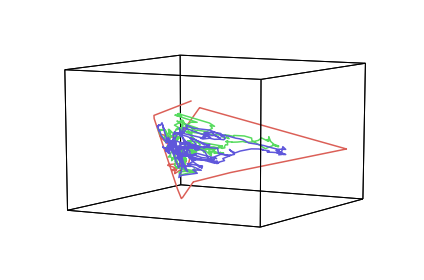

prediction


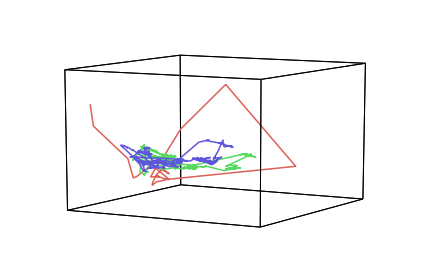

delayed


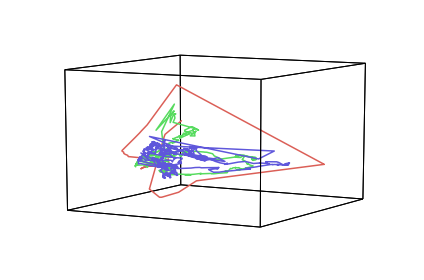

recall


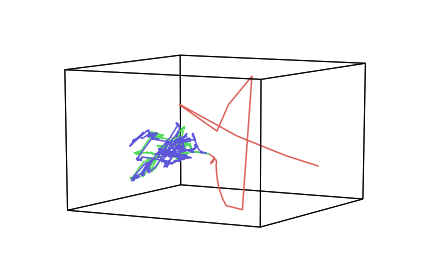

recall


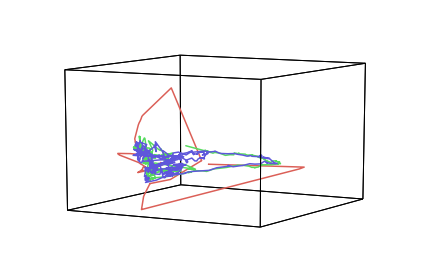

prediction


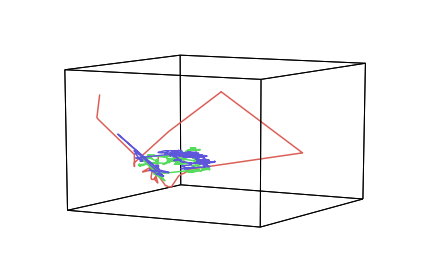

delayed


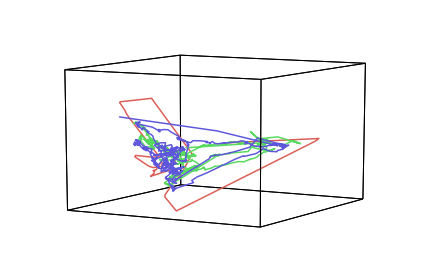

recall


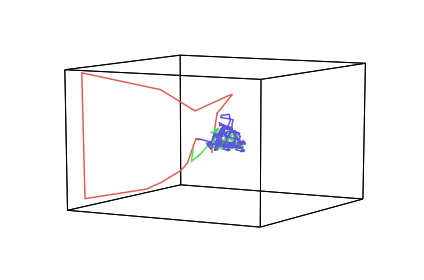

recall


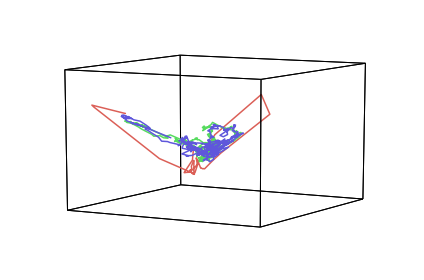

prediction


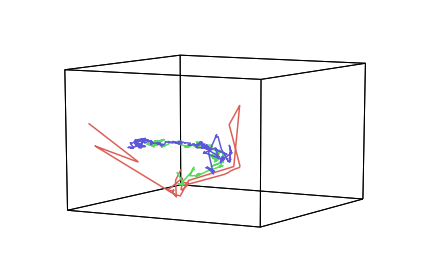

delayed


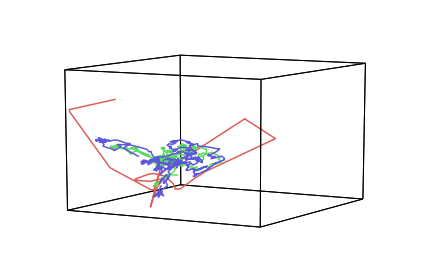

recall


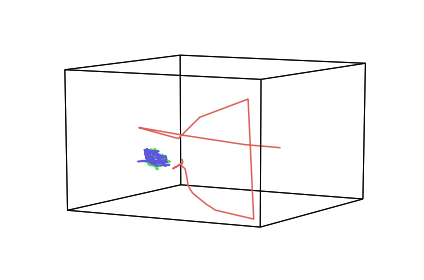

recall


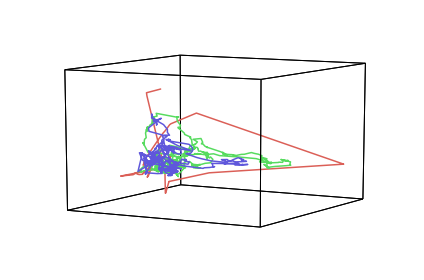

prediction


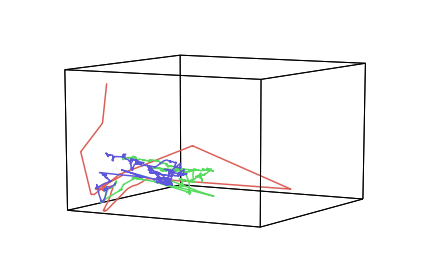

delayed


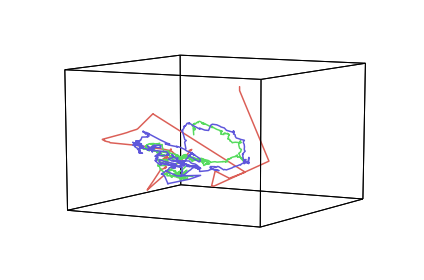

recall


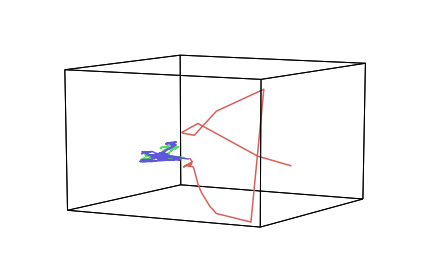

recall


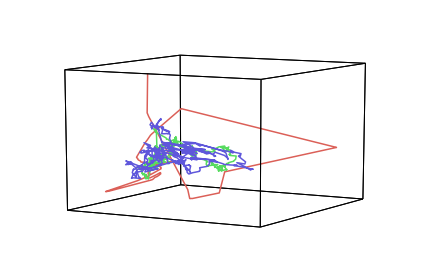

prediction


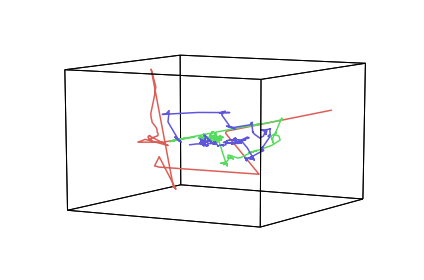

delayed


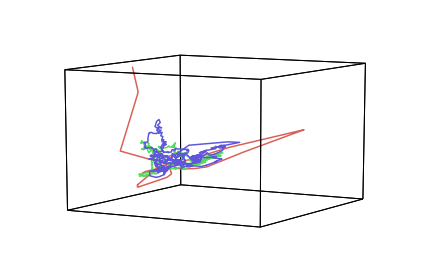

recall


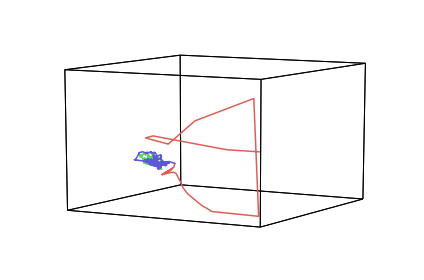

In [106]:
for tid, data in rec_models_dict.items():
    for rectype, method in data.items():
        print(rectype)
        hyp.plot([atlep1_model,method['automatic'],method['manual']])

In [80]:
np.shape(rec_models_dict['debug27k0b:debugOGsyi']['recall']['automatic'])

(535, 100)

In [81]:
np.shape(arrdev_model)

(535, 100)

In [94]:
len(transcript.split())

2680